# For defining, validating, and expnading scope of reaction templates

In [1]:
# File I/O
import json
from collections import defaultdict
from pathlib import Path

# Cheminformatics
from rdkit import Chem
from rdkit.Chem import rdChemReactions
from rdkit.Chem.Draw import ReactionToImage

# Custom Imports
from polymerist.rdutils.reactions.reactions import AnnotatedReaction

from polymerist.smileslib.functgroups import FN_GROUP_TABLE
from polymerist.polymers.monomers import specification

from src.reactions import rxn_assemblers, rxn_inputs, test_reactants_catalogue

## Inspecting defined reaction assemblers

### Define functional groups (with R-group linkers) as basis for desired reactions

polyester {2: (1, 5), 4: (5, 1)}


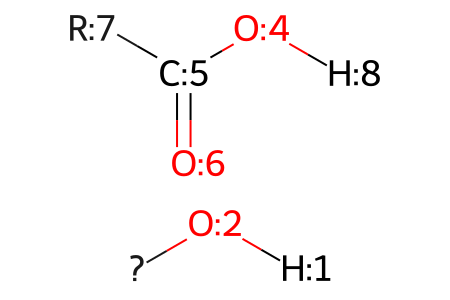

polyamide {1: (3, 6), 5: (6, 3)}


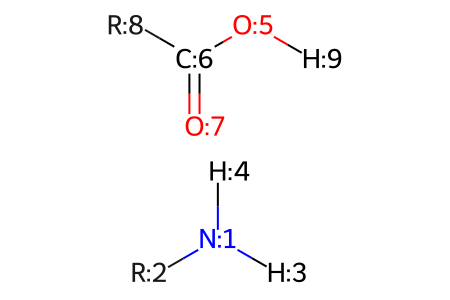

polyimide {4: (1, 8), 6: (8, 1), 3: (1, 8), 9: (8, 1)}


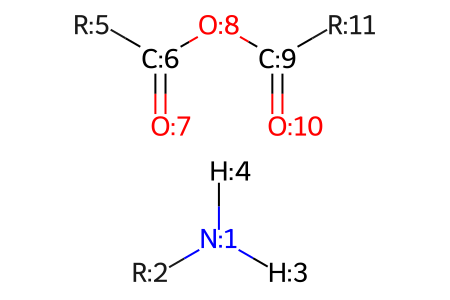

polycarbonate_phosgene {2: (1, 5), 4: (5, 1)}


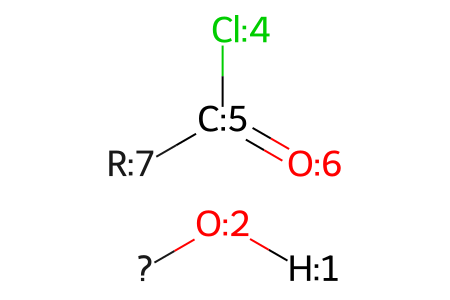

polycarbonate_nonphosgene {2: (1, 6), 5: (6, 1)}


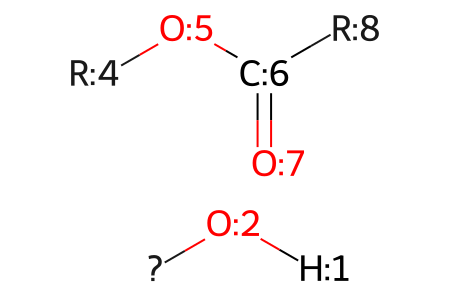

polyurethane_isocyanate {2: (1, 5), 6: (5, 1)}


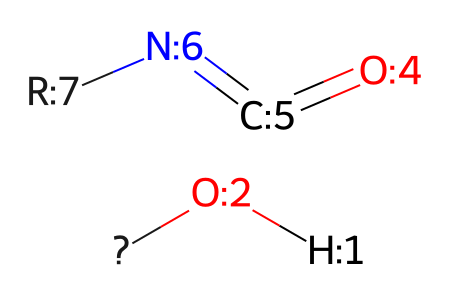

polyurethane_nonisocyanate {5: (4, 11), 13: (11, 4)}


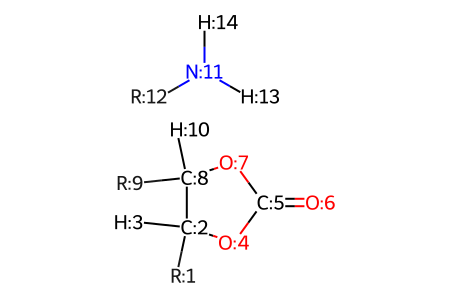

polyvinyl_head_tail {4: (2, 8), 12: (8, 2)}


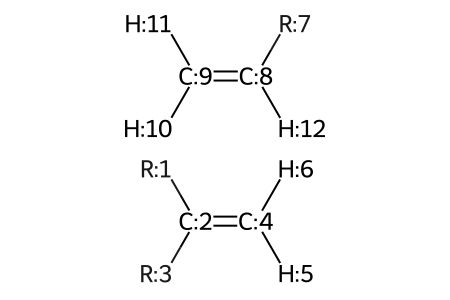

In [2]:
# display mechanism schemata prior to generating reactions (allows for inspection of derangement IDs)
for mech_name, mech_schema in rxn_assemblers.items():
    print(mech_name, mech_schema.bond_derangement)
    display(mech_schema.reactants)

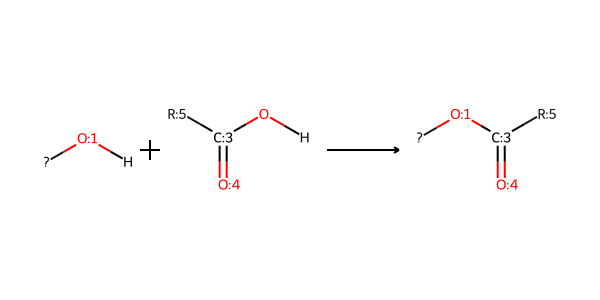

polyester


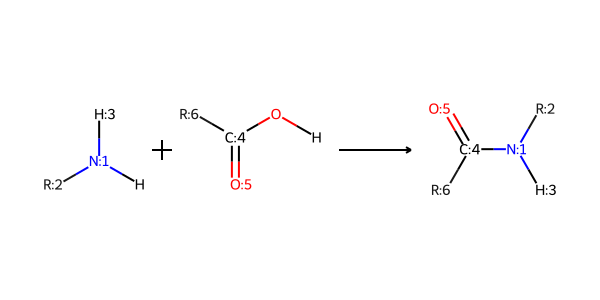

polyamide


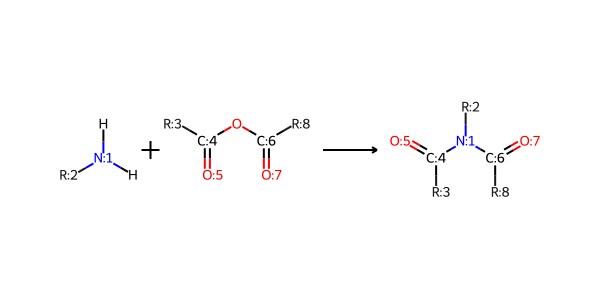

polyimide


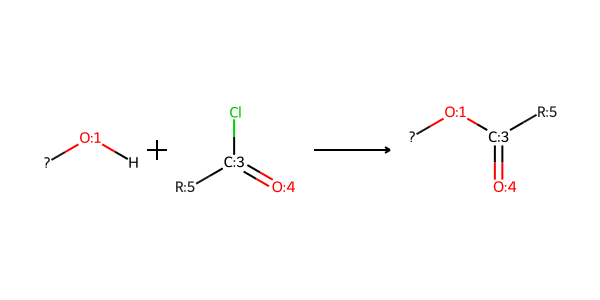

polycarbonate_phosgene


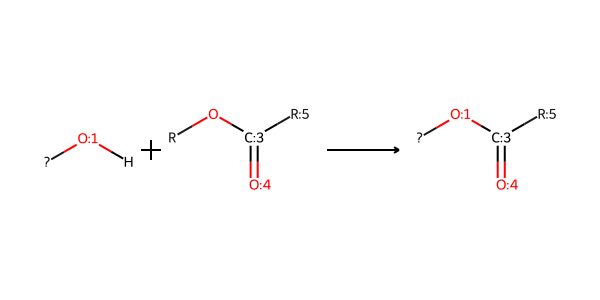

polycarbonate_nonphosgene


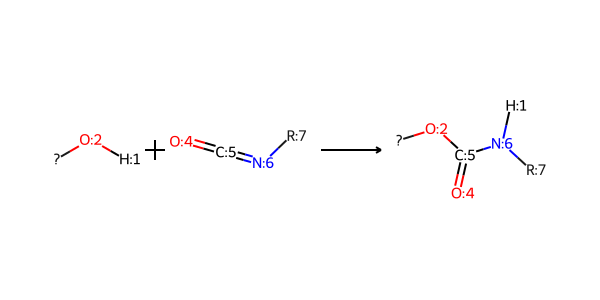

polyurethane_isocyanate


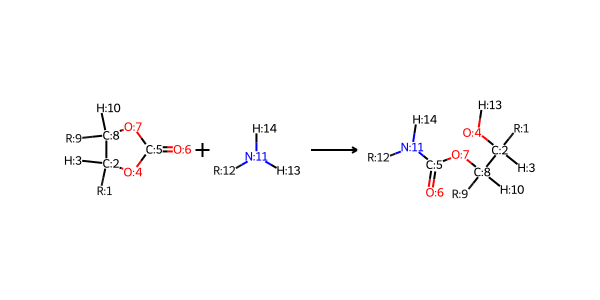

polyurethane_nonisocyanate


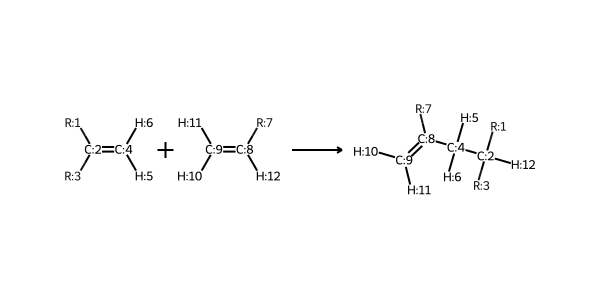

polyvinyl_head_tail


In [3]:
rxns : dict[str, AnnotatedReaction] = {}
for rxnname, rxn_assembler in rxn_assemblers.items():
    # assemble reaction
    rxn = rxn_assembler.assemble_rxn(show_steps=False) # placed here for consistency with display order 
    display(rxn)
    print(rxnname)
    
    rxn.rxnname = rxnname # store mechanism name for reference
    rxns[rxnname] = rxn

polyester


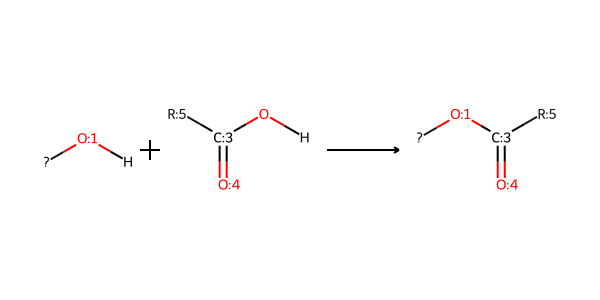

polyamide


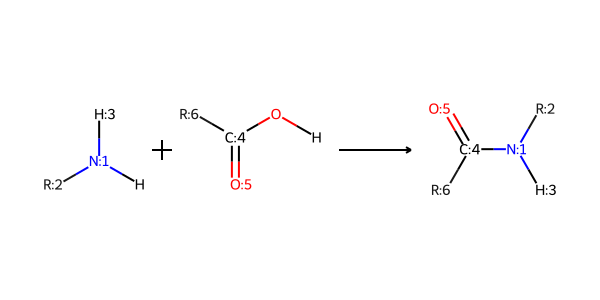

polyimide


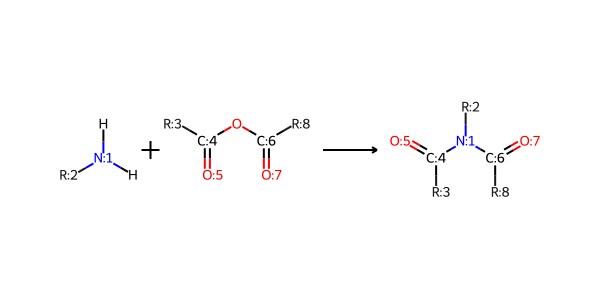

polycarbonate_phosgene


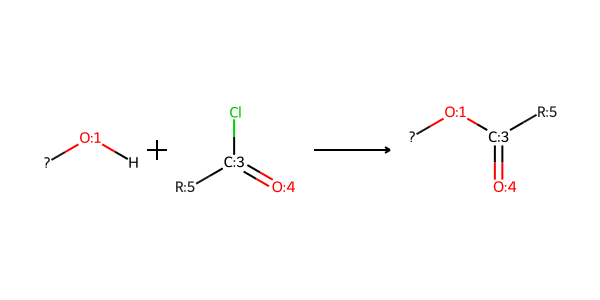

polycarbonate_nonphosgene


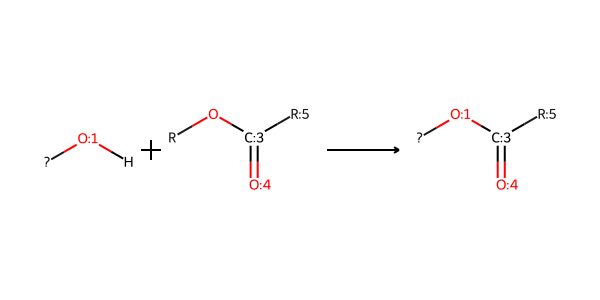

polyurethane_isocyanate


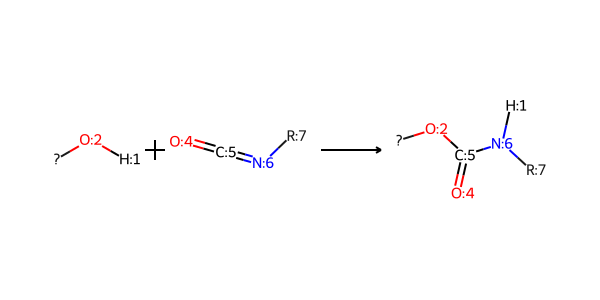

polyurethane_nonisocyanate


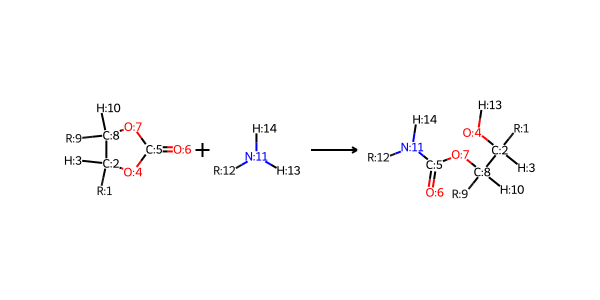

polyvinyl_head_tail


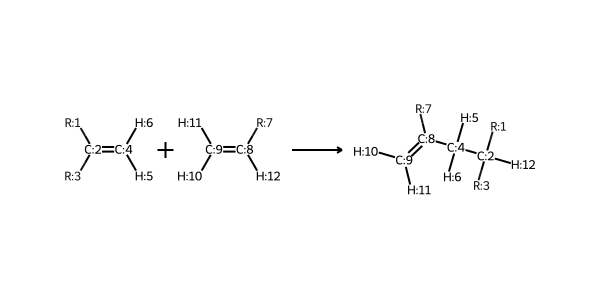

In [5]:
save_images : bool = True

rxn_img_dir = Path('rxn_images')
if save_images:
    rxn_img_dir.mkdir(exist_ok=True)

for rxnname, rxn in rxns.items():
    print(rxnname)
    display(rxn)

    if save_images:
        img = ReactionToImage(
            rxn=rxn,
            subImgSize=(200, 300),
            returnPNG=True,
        )
        with (rxn_img_dir/f'{rxnname}.png').open('wb') as file:
            file.write(img)

# Testing that reaction actually behave as intended

In [ ]:
# mechanism = 'polycarbonate_nonphosgene'
# mechanism = 'polyurethane_nonisocyanate'
# mechanism = 'polyimide'
mechanism = 'polyamide'

rxn = rxns[mechanism]
display(rxn)

test_reactants = test_reactants_catalogue[mechanism]
for reactant in test_reactants:
    display(reactant)

In [ ]:
from polymerist.rdutils.reactions import reactors

reactor = reactors.PolymerizationReactor(rxn)
for canon_smiles, product in reactor.propagate_pooled(test_reactants).items():
    print(canon_smiles)
    display(product)